# Financial Health Prediction

**Introduction** 
This is a ML challenge by Data.org on building models to assess the Financial Health Index of micro, small, and medium enterprises (MSMEs) across Southern Africa hosted by Zindi Africa.

**Aim**
The aim of this challenge is to assess the Financial Health Index of micro, small, and medium enterprises across 

**Obectives** 
 To classify businesses into Low, Medium, or High financial health across four key dimensions: savings and assests, debt and repayment, ability, resilience to shocks, and access to credit and financial services. 



## Imports and Setup

In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
#importing the warnings library to ignore any warnings that may arise during the execution of the code
import warnings
#ignoring any warnings that may arise during the execution of the code
warnings.filterwarnings('ignore')   


## Data Loading 

In [10]:
train = pd.read_csv ('Train.csv')
test = pd.read_csv ('Test.csv')
variable_definitions = pd.read_csv ('VariableDefinitions.csv')

## Dataset Overview

Objectives

1. Checking the dataset dimensions. 
2. Checking  the number of features in the dataset. 
3. Checking the presents of the target variable. 

In [11]:
#data dimensions
print(f"The train dataset has dimensions: {train.shape[0]} by {train.shape[1]}")
print(f"\nThe test dataset has dimensions: {test.shape[0]} by {test.shape[1]}")
print(f"\nThe number of features in the train dataset is:{train.shape[1]}")
print(f"\nThe number of features in the test dataset is:{test.shape[1]}")

#check target variable
if 'Target' in train.columns and 'target' not in test.columns:
    print(f"\nTarget variable found in train set")
    print("Target variable correctly absent from test set")
else:
    print("Target variable not found in train set")



The train dataset has dimensions: 9618 by 39

The test dataset has dimensions: 2405 by 38

The number of features in the train dataset is:39

The number of features in the test dataset is:38

Target variable found in train set
Target variable correctly absent from test set


In [12]:
display(variable_definitions)

,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatin...
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable bus...
4,attitude_worried_shutdown,Owner attitude: Worried that the business will...
5,compliance_income_tax,Business complies with or acts in accordance w...
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the...
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance paym...
8,personal_income,Total monthly personal income of the owner bef...
9,business_expenses,Approximate monthly or annual expenses of the ...


In [13]:
display(train.head(5))

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


In [14]:
display(test.head(5))


,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
0,ID_5EGLKX,zimbabwe,50.0,No,No,No,No,Yes,100.0,3600.0,...,NaN,NaN,NaN,No,8.0,Never had,Never had,NaN,NaN,NaN
1,ID_4AI7RE,lesotho,36.0,Yes,Yes,No,Yes,Yes,900.0,400.0,...,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now
2,ID_V9OB3M,lesotho,25.0,Don’t know or N/A,No,No,Don't know,Don't know,5250.0,350.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,No,Never had,Used to have but don't have now
3,ID_6OI9DI,malawi,25.0,Don’t know or N/A,Yes,No,No,Yes,485000.0,10000.0,...,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,Have now,Never had
4,ID_H2TN8B,lesotho,47.0,No,Yes,No,Don't know,Don't know,97.0,500.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now


# Target Variable Analysis
This section checks the distribution of the target variable to check for potential class imbalance. This is important when selecting the appropriate modelling and evaluation strategies. 

 Objectives: 
 1. To obtain the counts for each target class.
 2. To show the propotion of each class relative to the full data set. 

In [15]:
#counts of each target variable
print("Target Variable Analysis")
print("\nTarget Distibution")
print(train["Target"].value_counts())
print("\nTarget Percentage")
print(train["Target"].value_counts(normalize=True).sort_index().apply('{:.2%}'.format))

Target Variable Analysis

Target Distibution
Target
Low       6280
Medium    2868
High       470
Name: count, dtype: int64

Target Percentage
Target
High       4.89%
Low       65.29%
Medium    29.82%
Name: proportion, dtype: object


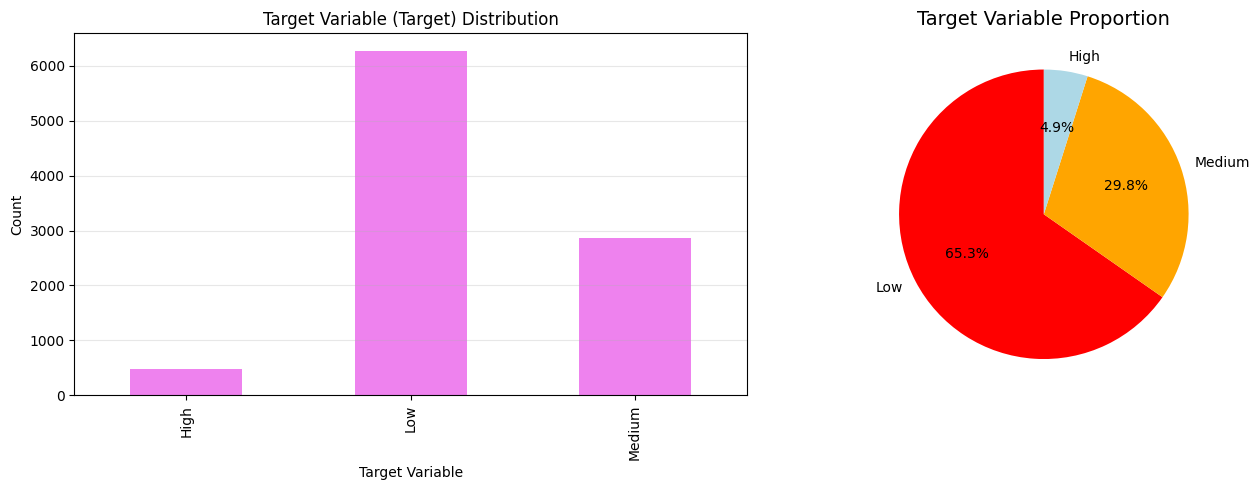


Class imbalance detected! Ratio: 13.36:1


In [16]:

#create a shell plot to visualize the target distribution. 
fig, axes = plt.subplots(1,2,figsize=(14,5))

#Count plot
train["Target"].value_counts().sort_index().plot(kind='bar', ax=axes[0], color="violet")
axes[0].set_title('Target Variable (Target) Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Target Variable')
axes[0].grid(axis='y', alpha=0.3)

t=train['Target'].value_counts()
axes[1].pie(t, labels= t.index,autopct='%1.1f%%',
            startangle=90, colors=['red', 'orange','lightblue'] )
axes[1].set_title('Target Variable Proportion', fontsize=14)

plt.tight_layout()
plt.show()

#check for class imbalance: 
class_ratio=train['Target'].value_counts().max()/train['Target'].value_counts().min()
if class_ratio > 1.5:
    print(f'\nClass imbalance detected! Ratio: {class_ratio:.2f}:1')
else: 
    print(f'Classes are relatively balanced. Ratio {class_ratio:.2f}:1')


## Dataset Information 

This section aims to provide a stucture overview of the training and testing datasets with the following objectives: 
1. To know the number of rows and columns in each dataset. 
2. To know and check if the columns match the varaible description. 
3. To know and correct for the data types of each feature. (Type casting).
4. To identify missing values, so that they can be handled accordingly. 



In [18]:
print("---TRAIN SET INFO---")
print(train.info())
print("---TEST SET INFO---")
print(test.info())

---TRAIN SET INFO---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9618 entries, 0 to 9617
Data columns (total 39 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ID                                                                9618 non-null   object 
 1   country                                                           9618 non-null   object 
 2   owner_age                                                         9618 non-null   float64
 3   attitude_stable_business_environment                              9616 non-null   object 
 4   attitude_worried_shutdown                                         9616 non-null   object 
 5   compliance_income_tax                                             9614 non-null   object 
 6   perception_insurance_doesnt_cover_losses                          9613 non-null   object 
 7   perception_c

## Missing Value Analysis
This section analyses missing data in both the training and test datasets, helping identify features that may rrequire imputation, transformation, or removal. 

Obectives: 
1. To calculate the number of missing values per column. 
2. To calculate the percentage of missing values relative to the dataset size. 
3. To filters and displays only columns that contain missing data. 
4. Sort columns by missing percentage. 

In [ ]:
#count the number of null in each column. 
train.isnull().sum() # train.isnull (True or False Train dataset on each entry.)
#missing values percentage
((train.isnull().sum()/len(train))*100).round(3)

# create a dataset that sorts the columns with missing values in descending order. 
# the dataset should have the following columns(column id, null count, percentage.)

ID                                                                   0.000
country                                                              0.000
owner_age                                                            0.000
attitude_stable_business_environment                                 0.021
attitude_worried_shutdown                                            0.021
compliance_income_tax                                                0.042
perception_insurance_doesnt_cover_losses                             0.052
perception_cannot_afford_insurance                                   0.052
personal_income                                                      1.133
business_expenses                                                    2.381
business_turnover                                                    2.246
business_age_years                                                   2.620
motor_vehicle_insurance                                             23.331
has_mobile_money         